# 07 Three-Way Model Comparison and Error Analysis

This notebook extends `05_model_comparison_and_error_analysis.ipynb` to include **PubMedBERT** alongside **TF-IDF + Logistic Regression** and **BioBERT**, producing a complete three-way comparison.

**Research questions answered here:**

- Which model achieves the best test-set performance overall?
- Does PubMedBERT improve over BioBERT, and by how much?
- On which *kinds* of examples does each transformer win over the baseline?
- Where do all three models still fail together?
- Which examples are the most useful for qualitative discussion in the thesis?


## Setup


In [1]:
from pathlib import Path
import json

import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

In [2]:
PROJECT_ROOT = Path(r'C:\Users\ribam\Desktop\Reseach\Dataset')
OUTPUT_ROOT  = PROJECT_ROOT / 'output'
COMPARE_DIR  = OUTPUT_ROOT / 'model_comparison_three_way'
COMPARE_DIR.mkdir(parents=True, exist_ok=True)

# --- metrics JSON paths ---
TFIDF_METRICS_PATH     = OUTPUT_ROOT / 'tfidf_logreg_metrics.json'
BIOBERT_METRICS_PATH   = OUTPUT_ROOT / 'biobert_fakehealth_healthfact'   / 'biobert_metrics.json'
PUBMED_METRICS_PATH    = OUTPUT_ROOT / 'pubmedbert_fakehealth_healthfact' / 'pubmedbert_metrics.json'

# --- prediction CSV paths ---
TFIDF_PRED_PATH   = OUTPUT_ROOT / 'tfidf_logreg_test_predictions.csv'
BIOBERT_PRED_PATH = OUTPUT_ROOT / 'biobert_fakehealth_healthfact'   / 'biobert_test_predictions.csv'
PUBMED_PRED_PATH  = OUTPUT_ROOT / 'pubmedbert_fakehealth_healthfact' / 'pubmedbert_test_predictions.csv'

TFIDF_METRICS_PATH, BIOBERT_METRICS_PATH, PUBMED_METRICS_PATH

(WindowsPath('C:/Users/ribam/Desktop/Reseach/Dataset/output/tfidf_logreg_metrics.json'),
 WindowsPath('C:/Users/ribam/Desktop/Reseach/Dataset/output/biobert_fakehealth_healthfact/biobert_metrics.json'),
 WindowsPath('C:/Users/ribam/Desktop/Reseach/Dataset/output/pubmedbert_fakehealth_healthfact/pubmedbert_metrics.json'))

## 1. Load Metrics


In [3]:
with open(TFIDF_METRICS_PATH,   'r', encoding='utf-8') as f:
    tfidf_metrics = json.load(f)

with open(BIOBERT_METRICS_PATH, 'r', encoding='utf-8') as f:
    biobert_metrics = json.load(f)

with open(PUBMED_METRICS_PATH,  'r', encoding='utf-8') as f:
    pubmed_metrics = json.load(f)

print('TF-IDF model    :', tfidf_metrics['model'])
print('BioBERT model   :', biobert_metrics['model_name'])
print('PubMedBERT model:', pubmed_metrics['model_name'])

TF-IDF model    : TF-IDF + Logistic Regression
BioBERT model   : dmis-lab/biobert-base-cased-v1.1
PubMedBERT model: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext


## 2. Three-Way Metric Comparison Table


In [4]:
def prediction_metrics(y_true, y_pred):
    reliable_precision, reliable_recall, reliable_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=1, zero_division=0
    )
    misinfo_precision, misinfo_recall, misinfo_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=0, zero_division=0
    )
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "test_accuracy": float(accuracy_score(y_true, y_pred)),
        "test_precision": float(reliable_precision),
        "test_recall": float(reliable_recall),
        "test_f1": float(reliable_f1),
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1),
        "misinformation_precision": float(misinfo_precision),
        "misinformation_recall": float(misinfo_recall),
        "misinformation_f1": float(misinfo_f1),
        "reliable_precision": float(reliable_precision),
        "reliable_recall": float(reliable_recall),
        "reliable_f1": float(reliable_f1),
    }


JOIN_KEYS = ["dataset", "split", "record_id", "label"]

tfidf_pred = pd.read_csv(TFIDF_PRED_PATH).rename(columns={
    "prediction": "tfidf_prediction",
    "prob_class_0": "tfidf_prob_0",
    "prob_class_1": "tfidf_prob_1",
})
biobert_pred = pd.read_csv(BIOBERT_PRED_PATH).rename(columns={
    "prediction": "biobert_prediction",
    "prob_class_0": "biobert_prob_0",
    "prob_class_1": "biobert_prob_1",
})
pubmed_pred = pd.read_csv(PUBMED_PRED_PATH).rename(columns={
    "prediction": "pubmed_prediction",
    "prob_class_0": "pubmed_prob_0",
    "prob_class_1": "pubmed_prob_1",
})


def existing_columns(frame, columns):
    return [column for column in columns if column in frame.columns]


tfidf_keep = existing_columns(
    tfidf_pred,
    JOIN_KEYS + ["text", "model_text", "tfidf_prediction", "tfidf_prob_0", "tfidf_prob_1"],
)
biobert_keep = existing_columns(
    biobert_pred,
    JOIN_KEYS + ["biobert_prediction", "biobert_prob_0", "biobert_prob_1"],
)
pubmed_keep = existing_columns(
    pubmed_pred,
    JOIN_KEYS + ["pubmed_prediction", "pubmed_prob_0", "pubmed_prob_1"],
)

merged = (
    tfidf_pred[tfidf_keep]
    .merge(biobert_pred[biobert_keep], on=JOIN_KEYS, how="inner")
    .merge(pubmed_pred[pubmed_keep], on=JOIN_KEYS, how="inner")
)

model_prediction_columns = {
    "TF-IDF + Logistic Regression": "tfidf_prediction",
    "BioBERT": "biobert_prediction",
    "PubMedBERT": "pubmed_prediction",
}
merged["majority_prediction"] = (
    merged[list(model_prediction_columns.values())].sum(axis=1) >= 2
).astype(int)
model_prediction_columns["Majority Vote"] = "majority_prediction"

metric_rows = []
for model_name, pred_col in model_prediction_columns.items():
    row = {"model": model_name, "metrics_source": "recalculated_from_prediction_csv"}
    row.update(prediction_metrics(merged["label"], merged[pred_col]))

    if model_name == "TF-IDF + Logistic Regression":
        row.update({
            "dev_accuracy": tfidf_metrics["dev_metrics"].get("accuracy"),
            "dev_precision": tfidf_metrics["dev_metrics"].get("precision"),
            "dev_recall": tfidf_metrics["dev_metrics"].get("recall"),
            "dev_f1": tfidf_metrics["dev_metrics"].get("f1"),
        })
    elif model_name == "BioBERT":
        row.update({
            "dev_accuracy": biobert_metrics["dev_metrics"].get("eval_accuracy"),
            "dev_precision": biobert_metrics["dev_metrics"].get("eval_precision"),
            "dev_recall": biobert_metrics["dev_metrics"].get("eval_recall"),
            "dev_f1": biobert_metrics["dev_metrics"].get("eval_f1"),
        })
    elif model_name == "PubMedBERT":
        row.update({
            "dev_accuracy": pubmed_metrics["dev_metrics"].get("eval_accuracy"),
            "dev_precision": pubmed_metrics["dev_metrics"].get("eval_precision"),
            "dev_recall": pubmed_metrics["dev_metrics"].get("eval_recall"),
            "dev_f1": pubmed_metrics["dev_metrics"].get("eval_f1"),
        })
    else:
        row.update({"dev_accuracy": np.nan, "dev_precision": np.nan, "dev_recall": np.nan, "dev_f1": np.nan})
    metric_rows.append(row)

comparison_df = pd.DataFrame(metric_rows)
comparison_df.to_csv(COMPARE_DIR / "model_metric_comparison.csv", index=False)

print("Merged prediction rows:", len(merged))
comparison_df.round(4)


Merged prediction rows: 1317


,model,metrics_source,test_accuracy,test_precision,test_recall,test_f1,macro_precision,macro_recall,macro_f1,misinformation_precision,misinformation_recall,misinformation_f1,reliable_precision,reliable_recall,reliable_f1,dev_accuracy,dev_precision,dev_recall,dev_f1
0,TF-IDF + Logistic Regression,recalculated_from_prediction_csv,0.7206,0.7933,0.7208,0.7553,0.7136,0.7205,0.7148,0.6339,0.7202,0.6743,0.7933,0.7208,0.7553,0.7227,0.7809,0.7589,0.7697
1,BioBERT,recalculated_from_prediction_csv,0.7563,0.7945,0.7995,0.7970,0.7465,0.7457,0.7461,0.6985,0.6919,0.6952,0.7945,0.7995,0.7970,0.7638,0.7930,0.8299,0.8110
2,PubMedBERT,recalculated_from_prediction_csv,0.7403,0.7989,0.7563,0.7771,0.7313,0.7364,0.7331,0.6637,0.7164,0.6891,0.7989,0.7563,0.7771,0.7608,0.8019,0.8078,0.8049
3,Majority Vote,recalculated_from_prediction_csv,0.7540,0.8102,0.7690,0.7891,0.7452,0.7503,0.7470,0.6801,0.7316,0.7049,0.8102,0.7690,0.7891,NaN,NaN,NaN,NaN


In [5]:
comparison_df.to_csv(COMPARE_DIR / 'model_metric_comparison.csv', index=False)
print('Saved metric comparison to', COMPARE_DIR / 'model_metric_comparison.csv')

Saved metric comparison to C:\Users\ribam\Desktop\Reseach\Dataset\output\model_comparison_three_way\model_metric_comparison.csv


## 3. F1 / Accuracy Bar Chart (Test Set)

Side-by-side grouped bars for Accuracy, Precision, Recall, and F1 across all three models.


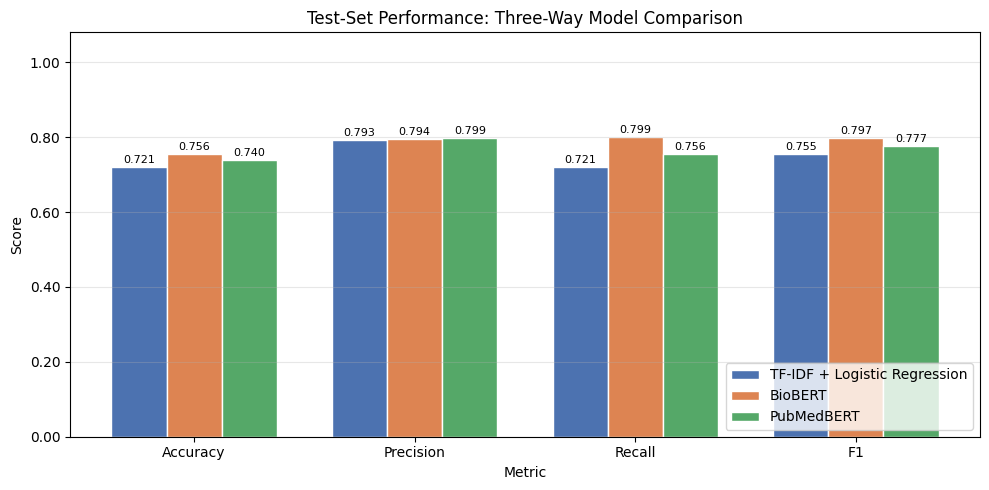

Saved bar chart to C:\Users\ribam\Desktop\Reseach\Dataset\output\model_comparison_three_way\test_metric_bar_chart.png


In [6]:
metrics_to_plot = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1']
metric_labels   = ['Accuracy', 'Precision', 'Recall', 'F1']
models          = comparison_df['model'].tolist()
colors          = ['#4C72B0', '#DD8452', '#55A868']   # TF-IDF, BioBERT, PubMedBERT

x     = np.arange(len(metric_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, (model, color) in enumerate(zip(models, colors)):
    row    = comparison_df[comparison_df['model'] == model].iloc[0]
    values = [row[m] for m in metrics_to_plot]
    bars   = ax.bar(x + (i - 1) * width, values, width, label=model, color=color, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8
        )

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Test-Set Performance: Three-Way Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(COMPARE_DIR / 'test_metric_bar_chart.png', dpi=150)
plt.show()
print('Saved bar chart to', COMPARE_DIR / 'test_metric_bar_chart.png')

## 4. F1 Delta Table — Gains Over Baseline

Shows how much each transformer improves (or regresses) on each metric versus the TF-IDF baseline.


In [7]:
baseline = comparison_df[comparison_df['model'] == 'TF-IDF + Logistic Regression'].iloc[0]

delta_rows = []
for _, row in comparison_df[comparison_df['model'] != 'TF-IDF + Logistic Regression'].iterrows():
    delta_rows.append({
        'model'              : row['model'],
        'Δ test_accuracy'    : round(row['test_accuracy']  - baseline['test_accuracy'],  4),
        'Δ test_precision'   : round(row['test_precision'] - baseline['test_precision'], 4),
        'Δ test_recall'      : round(row['test_recall']    - baseline['test_recall'],    4),
        'Δ test_f1'          : round(row['test_f1']        - baseline['test_f1'],        4),
    })

delta_df = pd.DataFrame(delta_rows)
delta_df

,model,Δ test_accuracy,Δ test_precision,Δ test_recall,Δ test_f1
0,BioBERT,0.0357,0.0012,0.0787,0.0416
1,PubMedBERT,0.0197,0.0056,0.0355,0.0217
2,Majority Vote,0.0334,0.0169,0.0482,0.0337


In [8]:
delta_df.to_csv(COMPARE_DIR / 'delta_vs_baseline.csv', index=False)
print('Saved delta table to', COMPARE_DIR / 'delta_vs_baseline.csv')

Saved delta table to C:\Users\ribam\Desktop\Reseach\Dataset\output\model_comparison_three_way\delta_vs_baseline.csv


## 5. Merge All Three Prediction Files

We join on `(dataset, split, record_id, label, text)` — the same key used in notebook 05 — so every row represents one test example with all three model predictions side-by-side.


In [9]:
print("Merged rows:", len(merged))
merged.head(3)


Merged rows: 1317


,dataset,split,record_id,label,text,model_text,tfidf_prediction,tfidf_prob_0,tfidf_prob_1,biobert_prediction,biobert_prob_0,biobert_prob_1,pubmed_prediction,pubmed_prob_0,pubmed_prob_1,majority_prediction
0,healthfact,test,33456,0,A mother revealed to her child in a letter aft...,A mother revealed to her child in a letter aft...,0,0.866750,0.133250,0,0.693878,0.306122,0,0.997241,0.002759,0
1,healthfact,test,2542,1,Study says too many Americans still drink too ...,Study says too many Americans still drink too ...,1,0.143167,0.856833,1,0.007271,0.992730,1,0.000200,0.999800,1
2,healthfact,test,26678,1,Viral image Says 80% of novel coronavirus case...,Viral image Says 80% of novel coronavirus case...,0,0.716531,0.283469,1,0.005124,0.994876,0,0.999379,0.000621,0


## 6. Eight-Bucket Analysis

With three binary correct/wrong signals there are **2³ = 8 possible buckets**. Naming convention: a bucket name lists the model(s) that got the example *correct*; `all_wrong` means all three failed.

| Bucket | TF-IDF | BioBERT | PubMedBERT |
|---|:---:|:---:|:---:|
| `all_correct` | ✓ | ✓ | ✓ |
| `tfidf_biobert_only` | ✓ | ✓ | ✗ |
| `tfidf_pubmed_only` | ✓ | ✗ | ✓ |
| `biobert_pubmed_only` | ✗ | ✓ | ✓ |
| `tfidf_only` | ✓ | ✗ | ✗ |
| `biobert_only` | ✗ | ✓ | ✗ |
| `pubmed_only` | ✗ | ✗ | ✓ |
| `all_wrong` | ✗ | ✗ | ✗ |


In [10]:
merged["tfidf_correct"] = merged["tfidf_prediction"] == merged["label"]
merged["biobert_correct"] = merged["biobert_prediction"] == merged["label"]
merged["pubmed_correct"] = merged["pubmed_prediction"] == merged["label"]
merged["majority_correct"] = merged["majority_prediction"] == merged["label"]

t = merged["tfidf_correct"]
b = merged["biobert_correct"]
p = merged["pubmed_correct"]

conditions = [
    (t & b & p, "all_correct"),
    (t & b & ~p, "tfidf_biobert_only"),
    (t & ~b & p, "tfidf_pubmed_only"),
    (~t & b & p, "biobert_pubmed_only"),
    (t & ~b & ~p, "tfidf_only"),
    (~t & b & ~p, "biobert_only"),
    (~t & ~b & p, "pubmed_only"),
    (~t & ~b & ~p, "all_wrong"),
]

merged["bucket"] = "unassigned"
for mask, name in conditions:
    merged.loc[mask, "bucket"] = name

bucket_counts = merged["bucket"].value_counts().reindex(
    [name for _, name in conditions], fill_value=0
)
bucket_counts


bucket
all_correct            756
tfidf_biobert_only      69
tfidf_pubmed_only       54
biobert_pubmed_only    114
tfidf_only              70
biobert_only            57
pubmed_only             51
all_wrong              146
Name: count, dtype: int64

In [11]:
bucket_summary = pd.DataFrame({
    'bucket' : bucket_counts.index,
    'count'  : bucket_counts.values,
    'percent': (bucket_counts.values / len(merged) * 100).round(2),
})
bucket_summary

,bucket,count,percent
0,all_correct,756,57.40
1,tfidf_biobert_only,69,5.24
2,tfidf_pubmed_only,54,4.10
3,biobert_pubmed_only,114,8.66
4,tfidf_only,70,5.32
5,biobert_only,57,4.33
6,pubmed_only,51,3.87
7,all_wrong,146,11.09


In [12]:
bucket_summary.to_csv(COMPARE_DIR / 'eight_bucket_summary.csv', index=False)
print('Saved bucket summary to', COMPARE_DIR / 'eight_bucket_summary.csv')

Saved bucket summary to C:\Users\ribam\Desktop\Reseach\Dataset\output\model_comparison_three_way\eight_bucket_summary.csv


### 6a. Bucket Bar Chart


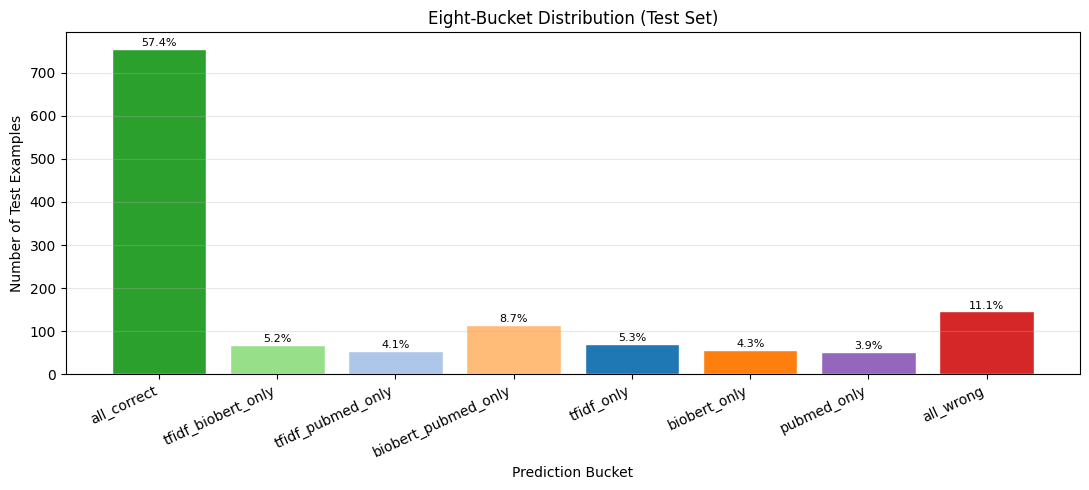

Saved bucket bar chart.


In [13]:
bucket_colors = [
    '#2ca02c',  # all_correct         — green
    '#98df8a',  # tfidf_biobert_only
    '#aec7e8',  # tfidf_pubmed_only
    '#ffbb78',  # biobert_pubmed_only
    '#1f77b4',  # tfidf_only          — blue
    '#ff7f0e',  # biobert_only        — orange
    '#9467bd',  # pubmed_only         — purple
    '#d62728',  # all_wrong           — red
]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(bucket_summary['bucket'], bucket_summary['count'], color=bucket_colors, edgecolor='white')
for bar, pct in zip(bars, bucket_summary['percent']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=8
    )
ax.set_xlabel('Prediction Bucket')
ax.set_ylabel('Number of Test Examples')
ax.set_title('Eight-Bucket Distribution (Test Set)')
plt.xticks(rotation=25, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(COMPARE_DIR / 'eight_bucket_bar_chart.png', dpi=150)
plt.show()
print('Saved bucket bar chart.')

## 7. Per-Dataset and Per-Label Breakdown


In [14]:
dataset_bucket = pd.crosstab(merged['dataset'], merged['bucket'])
label_bucket   = pd.crosstab(merged['label'],   merged['bucket'])

print('--- By Source Dataset ---')
display(dataset_bucket)

print('\n--- By True Label (0 = misinfo, 1 = reliable) ---')
display(label_bucket)

--- By Source Dataset ---


bucket,all_correct,all_wrong,biobert_only,biobert_pubmed_only,pubmed_only,tfidf_biobert_only,tfidf_only,tfidf_pubmed_only
dataset,,,,,,,,
curated_health_claims,4,1,0,1,0,0,0,0
fakehealth,98,56,25,39,19,37,28,22
healthfact,654,89,32,74,32,32,42,32



--- By True Label (0 = misinfo, 1 = reliable) ---


bucket,all_correct,all_wrong,biobert_only,biobert_pubmed_only,pubmed_only,tfidf_biobert_only,tfidf_only,tfidf_pubmed_only
label,,,,,,,,
0,276,66,13,46,23,31,40,34
1,480,80,44,68,28,38,30,20


In [15]:
dataset_bucket.to_csv(COMPARE_DIR / 'dataset_bucket_crosstab.csv')
label_bucket.to_csv(COMPARE_DIR / 'label_bucket_crosstab.csv')
print('Saved crosstabs.')

Saved crosstabs.


## 8. Per-Model Accuracy by Dataset

A quick sanity check: does one model do systematically better on FakeHealth vs HealthFact?


In [16]:
per_dataset_acc = []
for ds in sorted(merged["dataset"].dropna().unique()):
    sub = merged[merged["dataset"] == ds]
    per_dataset_acc.append({
        "dataset": ds,
        "n": len(sub),
        "tfidf_accuracy": round(sub["tfidf_correct"].mean(), 4),
        "biobert_accuracy": round(sub["biobert_correct"].mean(), 4),
        "pubmed_accuracy": round(sub["pubmed_correct"].mean(), 4),
        "majority_accuracy": round(sub["majority_correct"].mean(), 4),
    })

per_dataset_acc_df = pd.DataFrame(per_dataset_acc)
per_dataset_acc_df


,dataset,n,tfidf_accuracy,biobert_accuracy,pubmed_accuracy,majority_accuracy
0,curated_health_claims,6,0.6667,0.8333,0.8333,0.8333
1,fakehealth,324,0.5710,0.6142,0.5494,0.6049
2,healthfact,987,0.7700,0.8024,0.8024,0.8024


In [17]:
per_dataset_acc_df.to_csv(COMPARE_DIR / 'per_dataset_accuracy.csv', index=False)
print('Saved per-dataset accuracy.')

Saved per-dataset accuracy.


## 9. Qualitative Error Analysis

We pull out examples that are useful for thesis discussion:

1. **Both transformers win** (`biobert_pubmed_only`) - cases where domain knowledge helps.
2. **PubMedBERT only wins** (`pubmed_only`) - cases where PubMedBERT has an edge.
3. **TF-IDF only wins** (`tfidf_only`) - cases where lexical pattern matching beats contextual models.
4. **All three wrong** (`all_wrong`) - the hardest examples.
5. **Majority vote** is tracked separately in the merged file and summary, because it is the recommended app decision rule.


In [18]:
QUAL_COLS = [
    'dataset', 'record_id', 'label',
    'tfidf_prediction', 'biobert_prediction', 'pubmed_prediction',
    'biobert_prob_1', 'pubmed_prob_1',
    'text',
]

both_transformers_win = merged[merged['bucket'] == 'biobert_pubmed_only'][QUAL_COLS].copy()
pubmed_only_wins      = merged[merged['bucket'] == 'pubmed_only'][QUAL_COLS].copy()
tfidf_only_wins       = merged[merged['bucket'] == 'tfidf_only'][QUAL_COLS].copy()
all_wrong             = merged[merged['bucket'] == 'all_wrong'][QUAL_COLS].copy()

print('Both transformers win (biobert_pubmed_only):', len(both_transformers_win))
print('PubMedBERT only wins (pubmed_only)          :', len(pubmed_only_wins))
print('TF-IDF only wins (tfidf_only)               :', len(tfidf_only_wins))
print('All three wrong (all_wrong)                 :', len(all_wrong))

Both transformers win (biobert_pubmed_only): 114
PubMedBERT only wins (pubmed_only)          : 51
TF-IDF only wins (tfidf_only)               : 70
All three wrong (all_wrong)                 : 146


In [19]:
print('=== Both Transformers Win (sample 10) ===')
both_transformers_win.head(10)

=== Both Transformers Win (sample 10) ===


,dataset,record_id,label,tfidf_prediction,biobert_prediction,pubmed_prediction,biobert_prob_1,pubmed_prob_1,text
15,healthfact,29144,0,1,0,0,0.469302,0.001165,Queen Elizabeth II wore a Burmese Ruby Tiara a...
18,healthfact,9960,0,1,0,0,0.307445,0.001106,Scientists look to stem cells to mend broken h...
60,healthfact,10970,1,0,1,1,0.882062,0.999749,"To reverse damage of sitting, take a brisk, ho..."
66,healthfact,22800,1,0,1,1,0.721191,0.691133,The city of Atlanta has $56 million in its res...
67,healthfact,5571,1,0,1,1,0.991262,0.999643,CVI: The impairment affecting children whose e...
69,healthfact,28092,1,0,1,1,0.582132,0.770791,Immigration authorities are taking rosaries aw...
82,healthfact,33983,0,1,0,0,0.177540,0.000577,NASA and NOAA faked climate data in the GISTEM...
95,healthfact,15867,0,1,0,0,0.441728,0.004746,Drug Policy Alliance Says Debbie Wasserman Sch...
96,healthfact,2654,1,0,1,1,0.998960,0.999908,French breast implant boss arrested.
108,healthfact,33361,0,1,0,0,0.116942,0.001034,"HIV-positive basketball star Earvin ""Magic"" Jo..."


In [20]:
print('=== PubMedBERT Only Wins (sample 10) ===')
pubmed_only_wins.head(10)

=== PubMedBERT Only Wins (sample 10) ===


,dataset,record_id,label,tfidf_prediction,biobert_prediction,pubmed_prediction,biobert_prob_1,pubmed_prob_1,text
41,healthfact,13528,1,0,0,1,0.423676,0.945656,"Heroin comes in the United States ""from the so..."
68,healthfact,16390,0,1,1,0,0.510689,0.001494,"Leticia Van de Putte ""voted to give illegal im..."
89,healthfact,27567,1,0,0,1,0.385600,0.994638,The FDA has updated its warnings for — and rec...
97,healthfact,10507,1,0,0,1,0.353326,0.999612,The Healthy Skeptic: Products make testosteron...
121,healthfact,15271,0,1,1,0,0.957625,0.000695,"Dick Black Says Jill McCabe ""supports late ter..."
149,healthfact,35961,1,0,0,1,0.459335,0.757442,"Donald Trump Jr. tweeted, ""Do you know what's ..."
220,healthfact,38247,1,0,0,1,0.335563,0.934303,A letter by Dr. Keith Albow said President Tru...
244,healthfact,41044,1,0,0,1,0.452293,0.514812,"If you have a runny nose and sputum, you have ..."
247,healthfact,11043,0,1,1,0,0.512570,0.017604,Statin Drugs May Cut Risk of Kidney Trouble Af...
261,healthfact,12744,1,0,0,1,0.412346,0.990822,"There’s not one public study, and by public st..."


In [21]:
print('=== TF-IDF Only Wins (sample 10) ===')
tfidf_only_wins.head(10)

=== TF-IDF Only Wins (sample 10) ===


,dataset,record_id,label,tfidf_prediction,biobert_prediction,pubmed_prediction,biobert_prob_1,pubmed_prob_1,text
24,healthfact,16513,0,0,1,1,0.911958,0.800644,"Obamacare ""cuts seniors’ Medicare."
28,healthfact,28214,1,1,0,0,0.161079,0.000744,"People can fly with dogs, pot-bellied pigs, tu..."
76,healthfact,35389,1,1,0,0,0.490901,0.001573,Some grocery store receipts contain chemicals ...
84,healthfact,13872,1,1,0,0,0.417904,0.000680,"Illegal tobacco sales, price driven too high, ..."
122,healthfact,14822,0,0,1,1,0.562938,0.988716,"Donald Trump Says 25 percent of U.S. Muslims ""..."
126,healthfact,35313,1,1,0,0,0.355132,0.001705,A video shows the fluff of poplar trees burnin...
189,healthfact,9364,1,1,0,0,0.174890,0.000792,This Blood Test Could Help Predict If A Pregna...
197,healthfact,27274,1,1,0,0,0.274795,0.002396,Arizona State Senate candidate Bobby Wilson fa...
209,healthfact,18217,1,1,0,0,0.494420,0.326993,As a student at Occidental College in Los Ange...
227,healthfact,16302,0,0,1,1,0.621167,0.973622,"In 2013,"" Dan Patrick voted ""against funding t..."


In [22]:
print('=== All Three Wrong (sample 10) ===')
all_wrong.head(10)

=== All Three Wrong (sample 10) ===


,dataset,record_id,label,tfidf_prediction,biobert_prediction,pubmed_prediction,biobert_prob_1,pubmed_prob_1,text
23,healthfact,10667,0,1,1,1,0.589402,0.669533,Artificial Pancreas Continues to Show Promise
47,healthfact,8959,0,1,1,1,0.929802,0.993776,Too many people missing out on health benefits...
52,healthfact,16366,1,0,0,0,0.449937,0.003221,"Charlie Crist Says Rick Scott signed ""laws req..."
100,healthfact,9673,0,1,1,1,0.926211,0.999411,'Female Viagra' gets mixed reviews
106,healthfact,16846,1,0,0,0,0.167957,0.057316,After Massachusetts passed a mandatory health ...
107,healthfact,10748,1,0,0,0,0.062542,0.001935,"Humira Provides Effective, Non-Steroid Alterna..."
119,healthfact,33799,0,1,1,1,0.836950,0.998019,More women are victims of domestic violence on...
120,healthfact,12493,1,0,0,0,0.108980,0.000690,"An ""abortion procedure is actually safer than ..."
125,healthfact,27280,1,0,0,0,0.401395,0.469364,A Russian asbestos company placed a seal with ...
162,healthfact,35398,1,0,0,0,0.346112,0.002146,A video shows two people waving guns at protes...


In [23]:
both_transformers_win.to_csv(COMPARE_DIR / 'both_transformers_win_examples.csv',  index=False)
pubmed_only_wins.to_csv(     COMPARE_DIR / 'pubmed_only_correct_examples.csv',    index=False)
tfidf_only_wins.to_csv(      COMPARE_DIR / 'tfidf_only_correct_examples.csv',     index=False)
all_wrong.to_csv(            COMPARE_DIR / 'all_wrong_examples.csv',              index=False)
merged.to_csv(               COMPARE_DIR / 'full_merged_predictions.csv',         index=False)
print('Saved all qualitative analysis CSVs.')

Saved all qualitative analysis CSVs.


## 10. Summary JSON


In [24]:
best_reliable_f1 = comparison_df.sort_values("test_f1", ascending=False).iloc[0]
best_macro_f1 = comparison_df.sort_values("macro_f1", ascending=False).iloc[0]
best_misinfo_f1 = comparison_df.sort_values("misinformation_f1", ascending=False).iloc[0]

majority_row = comparison_df[comparison_df["model"] == "Majority Vote"].iloc[0]

summary = {
    "recommended_decision_rule": best_macro_f1["model"],
    "metrics_source": "recalculated_from_prediction_csv",
    "best_model_by_test_f1": best_reliable_f1["model"],
    "best_model_by_macro_f1": best_macro_f1["model"],
    "best_model_by_misinformation_f1": best_misinfo_f1["model"],
    "test_f1_scores": {
        row["model"]: round(float(row["test_f1"]), 6)
        for _, row in comparison_df.iterrows()
    },
    "macro_f1_scores": {
        row["model"]: round(float(row["macro_f1"]), 6)
        for _, row in comparison_df.iterrows()
    },
    "misinformation_f1_scores": {
        row["model"]: round(float(row["misinformation_f1"]), 6)
        for _, row in comparison_df.iterrows()
    },
    "majority_vote": {
        "accuracy": round(float(majority_row["test_accuracy"]), 6),
        "macro_f1": round(float(majority_row["macro_f1"]), 6),
        "misinformation_f1": round(float(majority_row["misinformation_f1"]), 6),
        "reliable_f1": round(float(majority_row["reliable_f1"]), 6),
    },
    "bucket_counts": bucket_summary.set_index("bucket")["count"].to_dict(),
    "total_test_examples": int(len(merged)),
}

(COMPARE_DIR / "comparison_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
summary


{'recommended_decision_rule': 'Majority Vote',
 'metrics_source': 'recalculated_from_prediction_csv',
 'best_model_by_test_f1': 'BioBERT',
 'best_model_by_macro_f1': 'Majority Vote',
 'best_model_by_misinformation_f1': 'Majority Vote',
 'test_f1_scores': {'TF-IDF + Logistic Regression': 0.755319,
  'BioBERT': 0.796964,
  'PubMedBERT': 0.777053,
  'Majority Vote': 0.789062},
 'macro_f1_scores': {'TF-IDF + Logistic Regression': 0.714828,
  'BioBERT': 0.74606,
  'PubMedBERT': 0.733072,
  'Majority Vote': 0.74699},
 'misinformation_f1_scores': {'TF-IDF + Logistic Regression': 0.674336,
  'BioBERT': 0.695157,
  'PubMedBERT': 0.689091,
  'Majority Vote': 0.704918},
 'majority_vote': {'accuracy': 0.753986,
  'macro_f1': 0.74699,
  'misinformation_f1': 0.704918,
  'reliable_f1': 0.789062},
 'bucket_counts': {'all_correct': 756,
  'tfidf_biobert_only': 69,
  'tfidf_pubmed_only': 54,
  'biobert_pubmed_only': 114,
  'tfidf_only': 70,
  'biobert_only': 57,
  'pubmed_only': 51,
  'all_wrong': 146},

## Next Step

The natural follow-on after this three-way comparison is:

- **`08_single_claim_inference.ipynb`** — a demo/testing notebook that loads the best-performing fine-tuned model and classifies a user-supplied health claim in real time, with confidence scores. This is the second option originally listed at the end of `05_model_comparison_and_error_analysis.ipynb`.
